In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import jax.numpy as jnp
from jax import jit, vmap, grad
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax

We aim at minimizing $$\mathcal{F}_P(Q) = \mathcal{L}(Q) + D_{KL}(Q||Q_0)$$ where $Q_0 = \mathcal{N}(0,I_d)$ and $P$ is the minimizer and has a positive density $$p(x) \propto q_0(x) \exp(-\mathcal{L}'(P)(x)).$$
To do this we run the stochastic process, for $k=1,...,T$,
$$X[k+1] = X[k] - \eta \nabla 
V(X[k]) + \sqrt{2 \eta} Z[k]$$
where 
- X[k] is a set of particules at recursion $k$ ($n$ particules in $\mathbb{R}^d$) (shape $(n,d)$)
- $n$ is the number of particules and $d$ the dimension
- $Z[1],...,Z[T]$ are iid gaussian noises (shape $(n,d)$)
- $\nabla V (X[k]) = \nabla_W \mathcal{L}(\hat{Q}[k])(X[k]) - \nabla \log q_0(X[k])$ where $\hat{Q}[k] = \frac1n \sum_{j=1}^n \delta_{X^j[k]}$.



# I/ IMQ Kernel  : $k(x,y) = \frac{1}{\sqrt{c + \|x-y\|^2}}$.

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [2]:
# sigma = 1
# def k(x,y):
#     return jnp.exp(-jnp.dot(x-y,x-y) / (2*sigma**2))

c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    d = len(x)
    return jnp.exp(-jnp.linalg.norm(x)**2/2) / jnp.sqrt((2 * jnp.pi)**d)
def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 
def L(X):
    return jnp.mean(v(X))

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In the following cell, for a number of iteration $T=500$, a number of $n$ particules in $\mathbb{R}^2$ we plot KGD and $\mathcal{F}_P$ evaluated on the last distribution of MFLD against the stepsize parameter $\eta$.

In [3]:
T = 500
n = 100 
d = 2
Eta = [0.0001,0.001,0.005,0.01,0.05,0.1,0.5,1.0,2.0,3.0,5.0]
n_sim = 3

KGD_fin = jnp.zeros(len(Eta))
F_P_fin = jnp.zeros(len(Eta))
all_particles_fin = jnp.zeros((len(Eta), n, d))

for e,eta in enumerate(Eta):
    for sim in range(n_sim):
        key = random.PRNGKey(100 + sim)  # Clé pseudo-aléatoire
        shape = (n, d)
        X0 = random.normal(key,shape) + 5* jnp.ones((n,d))

        KGD_values, F_P_values, all_particles = MFLD.run_particles(eta,T,X0)
        KGD_fin = KGD_fin.at[e].set(KGD_fin[e] + 1/n_sim * KGD_values[-1])
        F_P_fin = F_P_fin.at[e].set(F_P_fin[e] + 1/n_sim * F_P_values[-1])
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])
        


[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]
[-2.6265273 -2.4474287]
[-2.237315  -2.1818469]
[-2.9649596 -2.9926653]


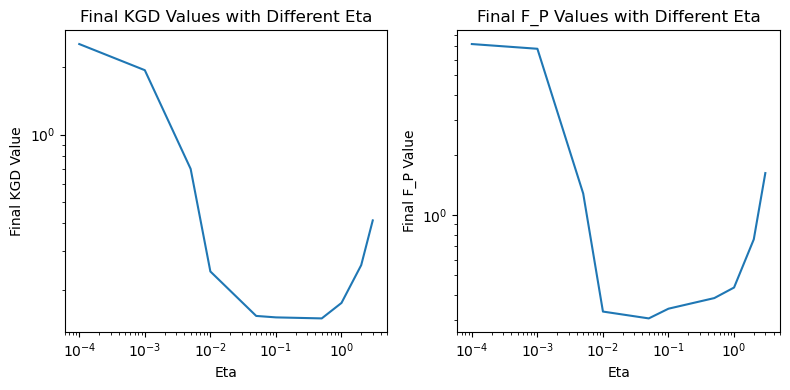

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  # 1 row, 2 columns, adjust figure size

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin)
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Final KGD Values with Different Eta')

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin + 1)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')   
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [6]:
# for e in range(len(Eta)):
#     plt.figure(figsize=(6, 6))
#     plt.title(f'Particles at Final Time Step for Eta={Eta[e]}')
#     key = random.PRNGKey(0)
#       # Clé pseudo-aléatoire
#     y = random.normal(key,shape = (n,d)) * jnp.sqrt(2)
#     plt.scatter(y[:,0], y[:,1], label='gaussian', alpha=0.5,marker = "x")
#     plt.scatter(all_particles_fin[e,:,0], all_particles_fin[e,:,1], label=f'Eta={Eta[e]}', alpha=0.5)
#     plt.legend()

# 2. Linear + Quadratic term 

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x) + \int \int w(x,x') \ d Q(x) d Q(x)$, with $v(x) = 1/2 \|x\|^2$ and $w(x,x') = x^Tx'$.

<!-- if w= 0
F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->

In [7]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) / jnp.sqrt((2  *jnp.pi)**d)
def v(x):
    return -1/4 * jnp.linalg.norm(x,axis = 1)**2
def w(X):
    _X = jax.lax.stop_gradient(X).T
    return jnp.dot(X,_X)
def L(X):
     return np.mean(v(X)) + np.mean(w(X))

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In [8]:
T = 500
n = 100 
d = 2
Eta = [0.001,0.005,0.01,0.05,0.1,0.2,0.5,1.0,2.0,5.0,10.0]
#Eta = np.logspace(-3, 0, 10)
X0 = np.random.randn(n, d)+ np.array([-5, 5])
n_sim = 3
KGD_fin = jnp.zeros(len(Eta))
F_P_fin = jnp.zeros(len(Eta))
all_particles_fin = jnp.zeros((len(Eta), n, d))

for e,eta in enumerate(Eta):
    for sim in range(n_sim):
        key = random.PRNGKey(100)  
        shape = (n, d)
        X0 = random.normal(key,shape) + 5* jnp.ones((n,d))
        
        KGD_values, F_P_values, all_particles = MFLD.run_particles(eta,T,X0)
        KGD_fin = KGD_fin.at[e].set(KGD_fin[e] + 1/n_sim * KGD_values[-1])
        F_P_fin = F_P_fin.at[e].set(F_P_fin[e] + 1/n_sim * F_P_values[-1])
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

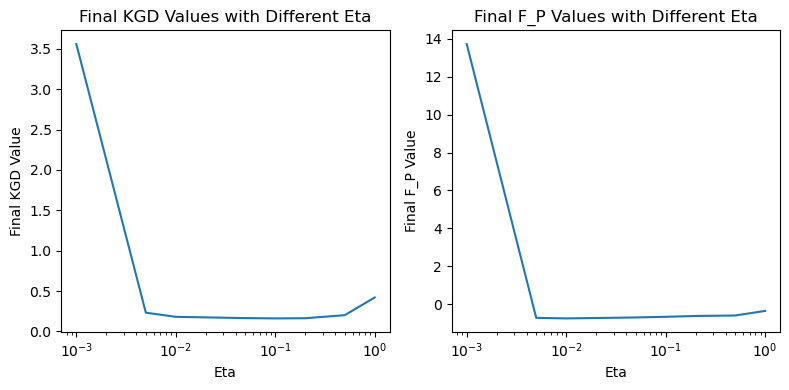

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin)
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')


plt.tight_layout()
plt.show()

<!-- In what follows we controll visually that the distribution converges to $\mathcal{N}(0,2 I_d)$. -->

# 3. MMD

### a) Q_1 is a Gaussian
- $\mathcal{L}(Q) = \frac{\gamma}{2} \textrm{MMD}(Q,Q_1)^2$
- $Q_1 = \mathcal{N}(\mu,\Sigma)$ where $\mu = (5,5)$, $\Sigma = I_d$
- Gaussian kernel in the MMD: $l(x,x') = \exp(-\frac{\|x-x'\|^2}{2 \sigma_l^2})$

In [44]:
c = 1.0
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y))) #(x-y,x-y)/(2*c**2))

x2 = jnp.array([5,5])
def q_0(x):
    return jnp.exp(-jnp.dot(x,x)/(2*4)) / jnp.sqrt((2* 4  *jnp.pi)**d)

sigma_l = 3.0
l = lambda x,y : ker.k_gauss(x,y,sigma_l) #Gram matrix for gaussian kernel = shape (n,m)

d = 2
Cov = np.diag(jnp.ones(d))
n1 = 70
mu = 5*np.ones(d)

key = random.PRNGKey(98)  
shape1 = (n1, d)
X1 = random.multivariate_normal(key,mu,Cov,n1)

gamma = 10
def L(X):
    _X = jax.lax.stop_gradient(X)
    return gamma/2 * (np.mean(l(X,_X)) - 2 * np.mean(l(X,X1)) + np.mean(l(X1,X1)))

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In [ ]:
T = 500
n = 50
#Eta = #[0.01,0.05,0.1]#,0.2,0.5,1.0,2.0,3.0,5.0,10.0,20.0,30.0,50.0,100.0]
Eta = np.logspace(-3,1,10)
n_sim = 1

KGD_fin = jnp.zeros(len(Eta))
F_P_fin = jnp.zeros(len(Eta))
all_particles_fin = jnp.zeros((len(Eta), n, d))

for e,eta in enumerate(Eta):
    for sim in range(n_sim):
        key = random.PRNGKey(100+sim)  
        shape = (n, d)
        X0 = random.normal(key,shape) + jnp.array([-5,5])

        KGD_values, F_P_values, all_particles = MFLD.run_particles(eta,T,X0,noise = 0)
        KGD_fin = KGD_fin.at[e].set(KGD_fin[e] + 1/n_sim * KGD_values[-1])
        F_P_fin = F_P_fin.at[e].set(F_P_fin[e] + 1/n_sim * F_P_values[-1])
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])
    # plt.figure()
    # plt.plot(KGD_values,label = "KGD")
    # plt.plot(F_P_values,label = "F_P")
    # plt.legend()


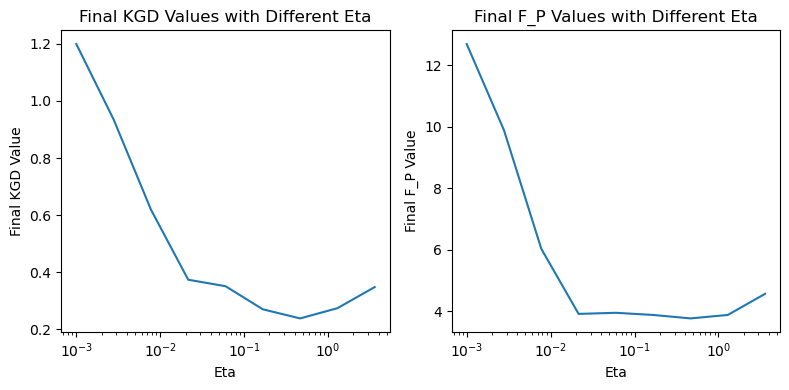

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

axes[0].plot(Eta, KGD_fin)
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')


axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')


plt.tight_layout()
plt.show()

Final particles postition : 

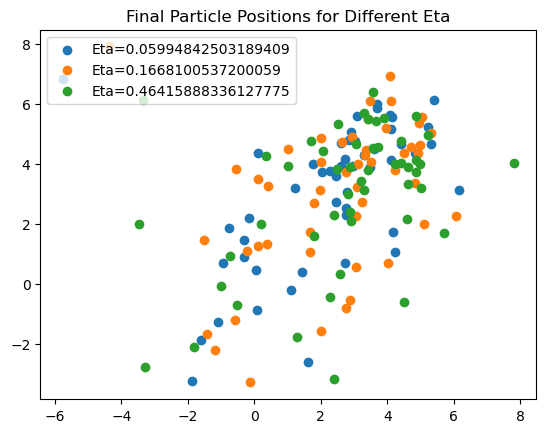

In [50]:
for e in range(4,len(Eta)-3):
    plt.scatter(all_particles_fin[e,:,0], all_particles_fin[e,:,1], label=f'Eta={Eta[e]}')
plt.title('Final Particle Positions for Different Eta')
plt.legend()

# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random

2 layer neural network :

In [2]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(rng, input_dim, hidden_dim):
    rng1, rng2 = random.split(rng)
    params = {
        'W1': random.normal(rng1, (hidden_dim, input_dim)) * 1.0,
        'b1': jnp.zeros(hidden_dim),
        'W2': random.normal(rng2, (1, hidden_dim)) * 1.0,
        'b2': jnp.zeros(1),
    }
    return params

def forward(params, z):
    h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
    y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
    return y.squeeze()


Generation of the data

In [ ]:
def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.normal(key_z, (N, s))  # Features z ∈ ℝ^s

    #explanation function
    def f(z):
        return jnp.sin(Z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N=300, noise_std=0.01)

$k$, $q_0$ and $\mathcal{L}$

In [ ]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/2) #/ jnp.sqrt((2 * jnp.pi)**d)


key = random.PRNGKey(0)
hidden_dim = 20
params = init_params(key, s, hidden_dim)  
flat_params, unravel_fn = ravel_pytree(params)
#lambd = 0.1


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
    return E
def L(X):
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)
 
MFLD = MeanFieldLangevinDynamics(q_0,L,k)    

In [6]:
T = 300
n = 20

Eta = jnp.logspace(-4,-2,8)
key = random.PRNGKey(14)
X_list = [init_params(random.fold_in(key, i), s, hidden_dim) for i in range(n)]
flat_X_list = [ravel_pytree(p)[0] for p in X_list]  # flatten
X0 = jnp.stack(flat_X_list)
d = len(X0[0])

n_sim = 1

KGD_fin = np.zeros(len(Eta))
F_P_fin = np.zeros(len(Eta))
all_particles_fin = np.zeros((len(Eta), n, d))

for e,eta in enumerate(Eta):
    for sim in range(n_sim):
        key = random.PRNGKey(100 + sim)
        X_list = [init_params(random.fold_in(key, i), s, hidden_dim) for i in range(n)]
        flat_X_list = [ravel_pytree(p)[0] for p in X_list]  # flatten
        X0 = jnp.stack(flat_X_list)
        KGD_values, F_P_values, all_particles = MFLD.run_particles(eta,T,X0)
        KGD_fin[e] += 1/n_sim * KGD_values[-1]
        F_P_fin[e] += 1/n_sim * F_P_values[-1]
    all_particles_fin[e] = all_particles[-1]



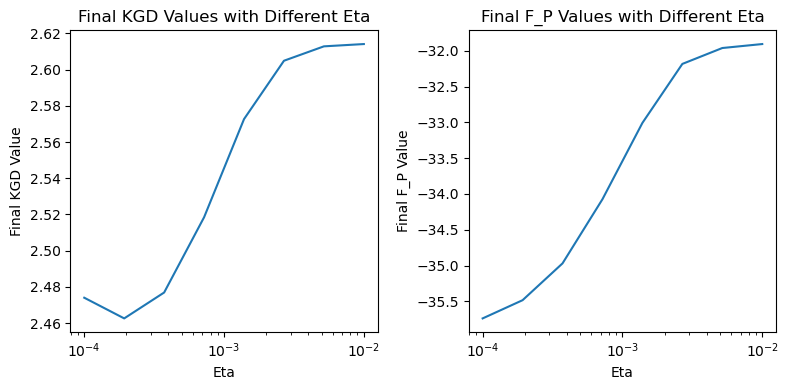

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin)
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

plt.tight_layout()
plt.show()

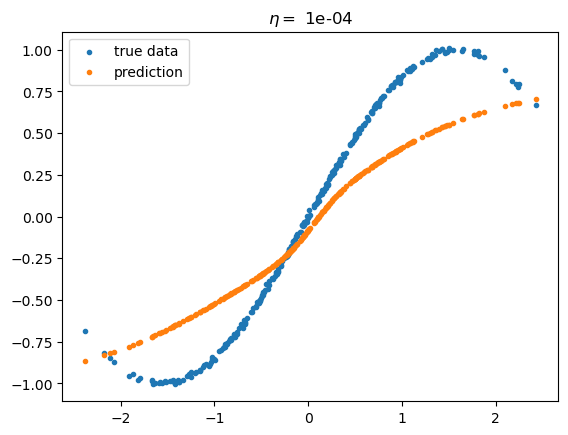

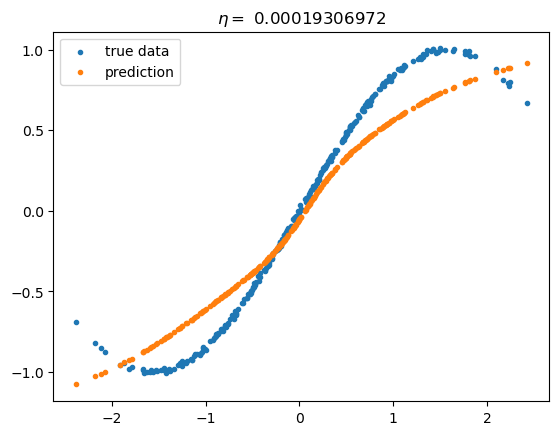

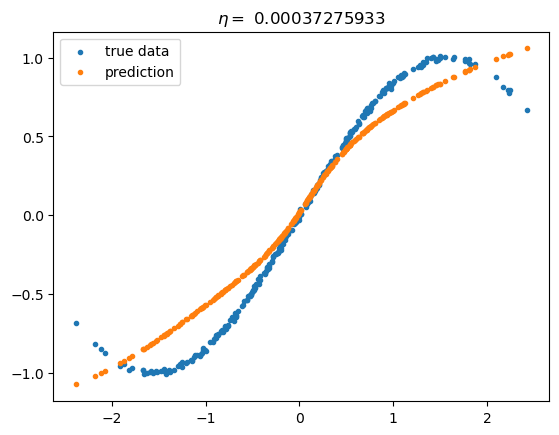

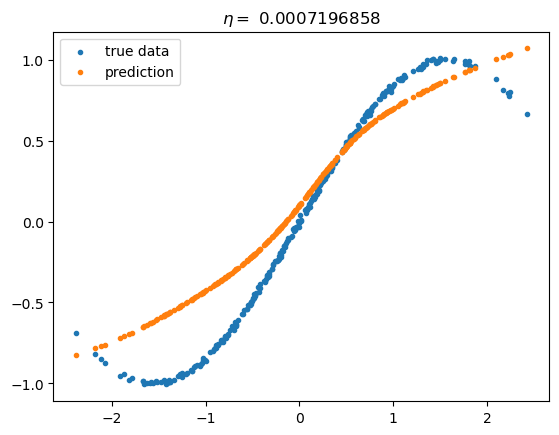

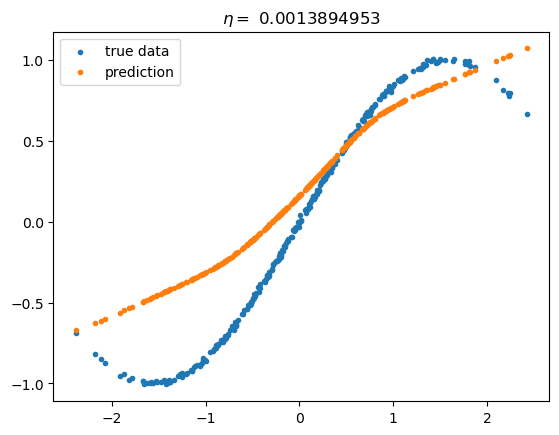

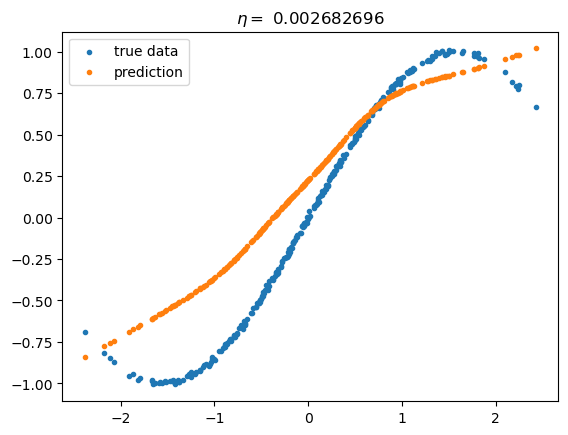

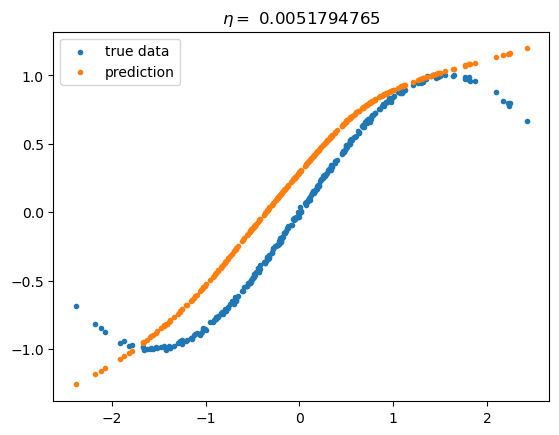

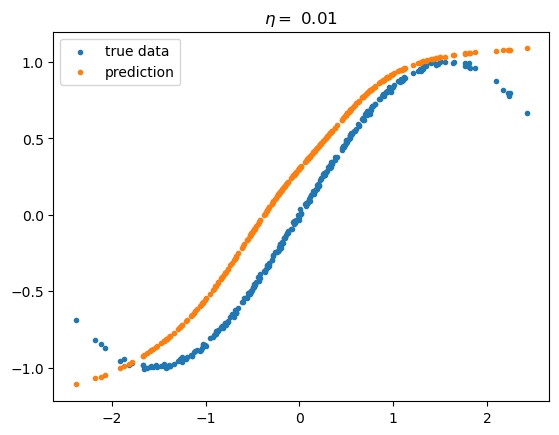

In [8]:
for e in range(len(Eta)):
    plt.figure()
    plt.scatter(Z,Y,label = "true data",marker = ".")
    X_fin = all_particles_fin[e]
    Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
    plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
    plt.legend()
    plt.title(r"$\eta = $ " + str(Eta[e]))

